# 02. EDA — 9 API + team1~4 신규 데이터 결합

1. 캐시·신규 데이터 모두 로드 → 자치구×업종×분기 통합 테이블 재구축
2. 11개 그래프로 첫인상 확인 (기존 9개 + 신규 임대료·공실률 2개)

산출물: `data/processed/integrated.csv` — 후속 노트북 입력

## 1. matplotlib 한글 폰트

In [1]:
# OS별 한글 폰트 자동 선택 — 차트의 자치구·업종명이 깨지지 않게
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

if platform.system() == 'Darwin':
    matplotlib.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
else:
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False              # 음수 부호 깨짐 방지

pd.set_option('display.max_columns', 60)

# 경로 상수
PROJECT_ROOT = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project')
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TEAM1_DIR = PROJECT_ROOT / 'data' / 'team1 이승직 (부동산, 임대료)'
TEAM3_DIR = PROJECT_ROOT / 'data' / 'team3 (행정동·미시 입지)'
TEAM4_DIR = PROJECT_ROOT / 'data' / 'team4'
print('READY')

READY


## 2. 자치구 매핑 (TRDAR_CD → 자치구명)

In [2]:
# 6개 분기 API의 TRDAR_CD를 자치구·행정동으로 변환할 매핑 사전
df_map = pd.read_csv(RAW_DIR / 'TbgisTrdarRelm.csv', dtype=str)        # dtype=str — 0 손실 방지
trdar_to_gu     = dict(zip(df_map['TRDAR_CD'], df_map['SIGNGU_CD_NM']))
trdar_to_adstrd = dict(zip(df_map['TRDAR_CD'], df_map['ADSTRD_CD']))
print('매핑 행:', len(trdar_to_gu))

매핑 행: 1650


## 3. 분기 CSV 로더 (재사용 헬퍼)

In [3]:
def load_quarterly(api: str) -> pd.DataFrame:
    """{api}_YYYYQ.csv 들을 모두 읽어 한 DataFrame으로 concat. TRDAR_CD가 있으면 자치구 컬럼도 자동 부여."""
    parts = []
    for p in sorted(RAW_DIR.glob(f'{api}_*.csv')):
        stem = p.stem
        q = stem.split('_')[-1]
        # 분기 식별자(5자리 숫자)가 아닌 파일은 스킵 (TbgisTrdarRelm 등)
        if not (q.isdigit() and len(q) == 5):
            continue
        df_q = pd.read_csv(p, encoding='utf-8-sig', low_memory=False)
        df_q['q'] = q                                             # 분기 컬럼 부여
        if 'TRDAR_CD' in df_q.columns:
            df_q['gu'] = df_q['TRDAR_CD'].astype(str).map(trdar_to_gu)  # TRDAR → 자치구 매핑
        parts.append(df_q)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)

print('load_quarterly 정의 완료')

load_quarterly 정의 완료


## 4. 매출 — 자치구·업종·분기 집계

In [4]:
# 매출 raw 로드 → (자치구, 업종, 분기) 단위로 합산
selng = load_quarterly('VwsmTrdarSelngQq')
print('매출 raw:', selng.shape)

# 합산 대상 컬럼 자동 추출 — 시간대/요일/연령/성별 매출액 + 건수 모두 포함
amt_cols = [c for c in selng.columns if c.endswith('_SELNG_AMT')] + ['THSMON_SELNG_AMT']
co_cols  = [c for c in selng.columns if c.endswith('_SELNG_CO')]  + ['THSMON_SELNG_CO']

selng['biz'] = selng['SVC_INDUTY_CD_NM']                                  # 업종 한글명 컬럼
# (gu, biz, q) 단위로 모든 매출액·건수 컬럼 합산 → 한 상권 안의 여러 TRDAR_CD가 합쳐짐
agg_sales = (selng.groupby(['gu', 'biz', 'q'], as_index=False)
                  [list(set(amt_cols + co_cols))].sum())
print('자치구×업종×분기 매출:', agg_sales.shape)

매출 raw: (72000, 57)
자치구×업종×분기 매출: (25044, 51)


## 5. 매출 상위 N 업종 한정 — N=50으로 확장 (이전 10 → 50)

raw 매출 데이터에 62개 업종이 있다. 매출 누적 99%를 커버하는 상위 50개를 사용해 모델 학습 범위를 확장한다.
(시각화는 가독성 위해 일부 그래프에서 상위 10·15만 표시)

In [5]:
# 매출 합 기준 상위 50업종 (이전 10 → 50으로 확장)
TOP_N_BIZ = 50
top_biz = (agg_sales.groupby('biz')['THSMON_SELNG_AMT'].sum()
                     .sort_values(ascending=False).head(TOP_N_BIZ).index.tolist())
print(f'상위 {len(top_biz)}업종 선택')
print('  처음 10:', top_biz[:10])
print('  마지막 10:', top_biz[-10:])
agg_sales = agg_sales[agg_sales['biz'].isin(top_biz)].copy()
print('필터 후:', agg_sales.shape)

상위 50업종 선택
  처음 10: ['한식음식점', '컴퓨터및주변장치판매', '수산물판매', '일반의류', '의약품', '일반의원', '편의점', '슈퍼마켓', '반찬가게', '커피-음료']
  마지막 10: ['스포츠 강습', '외국어학원', '미곡판매', '피부관리실', 'PC방', '화초', '인테리어', '섬유제품', '여관', '전자상거래업']
필터 후: (22099, 51)


## 6. 점포·유동·직장·집객·변화 결합

In [6]:
def to_num(df, cols):
    """문자열 → 숫자 변환 헬퍼 (변환 실패 시 NaN)."""
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

# 점포: (gu, biz, q) 단위
stor = load_quarterly('VwsmTrdarStorQq')
stor['biz'] = stor['SVC_INDUTY_CD_NM']
stor = to_num(stor, ['STOR_CO','OPBIZ_RT','CLSBIZ_RT'])                  # 점포수·개업률·폐업률
stor_agg = stor.groupby(['gu','biz','q'], as_index=False)[['STOR_CO','OPBIZ_RT','CLSBIZ_RT']].sum()

# 유동인구: (gu, q) 단위 — 업종 무관
flpop = load_quarterly('VwsmTrdarFlpopQq')
fl_cols = ['TOT_FLPOP_CO','ML_FLPOP_CO','FML_FLPOP_CO',
           'TMZON_11_14_FLPOP_CO','TMZON_17_21_FLPOP_CO','SAT_FLPOP_CO','SUN_FLPOP_CO']
flpop = to_num(flpop, fl_cols)
flpop_agg = flpop.groupby(['gu','q'], as_index=False)[fl_cols].sum()

# 직장인구: 정적 변수 (API가 분기 필터 무시 → 자치구 평균으로 사용)
wrc = load_quarterly('VwsmTrdarWrcPopltnQq')
wrc = to_num(wrc, ['TOT_WRC_POPLTN_CO'])
wrc_static = wrc.groupby('gu', as_index=False)['TOT_WRC_POPLTN_CO'].mean()

# 집객시설: 정적 변수
fcl = load_quarterly('VwsmTrdarFcltyQq')
fcl_cols = ['SUBWAY_STATN_CO','BUS_STTN_CO','UNIV_CO','GNRL_HSPTL_CO','PBLOFC_CO']
fcl = to_num(fcl, fcl_cols)
fcl_static = fcl.groupby('gu', as_index=False)[fcl_cols].mean()

# 변화지표: (gu, q) 단위, 최빈 카테고리 추출
ix = load_quarterly('VwsmTrdarIxQq')
ix = to_num(ix, ['OPR_SALE_MT_AVRG'])

# 변화 카테고리(다이나믹/정체/쇠퇴 등) — 자치구·분기별 최빈
chg = (ix.dropna(subset=['TRDAR_CHNGE_IX_NM'])
         .groupby(['gu','q'])['TRDAR_CHNGE_IX_NM']
         .agg(lambda s: s.value_counts().index[0])         # 최빈 1개
         .reset_index().rename(columns={'TRDAR_CHNGE_IX_NM':'CHG_DOMINANT'}))
opr = ix.groupby(['gu','q'], as_index=False)['OPR_SALE_MT_AVRG'].mean()
ix_agg = opr.merge(chg, on=['gu','q'], how='left')

print('점포', stor_agg.shape, '유동', flpop_agg.shape, '변화', ix_agg.shape)

점포 (37037, 6) 유동 (600, 9) 변화 (600, 4)


## 7. 문화행사 — STRTDATE → 분기 파생

In [7]:
# 문화행사 API는 분기 코드를 직접 안 줌 → 시작일에서 분기 파생
df_event = pd.read_csv(RAW_DIR / 'culturalEventInfo.csv')
df_event['STRTDATE'] = pd.to_datetime(df_event['STRTDATE'], errors='coerce')
df_event = df_event.dropna(subset=['STRTDATE','GUNAME'])
# 분기 = YYYY * 10 + (월-1)/3 + 1 → '20231' 같은 문자열
df_event['q'] = (df_event['STRTDATE'].dt.year.astype(str)
                 + ((df_event['STRTDATE'].dt.month - 1)//3 + 1).astype(str))
event_count = df_event.groupby(['GUNAME','q']).size().reset_index(name='event_count').rename(columns={'GUNAME':'gu'})
print('행사 카운트:', event_count.shape)

행사 카운트: (126, 3)


## 8. 신규 외부 데이터 로드

In [8]:
# 01에서 정리한 processed 파일 + team1 마진 detail 로드
rent = pd.read_csv(PROCESSED_DIR / 'team1_rent_gu_q.csv')
rent['q'] = rent['q'].astype(int).astype(str)                              # 매출 테이블의 q와 dtype 일치

margin = pd.read_csv(TEAM1_DIR / 'team1_margin_proxy_detail.csv')
margin['q'] = margin['q'].astype(int).astype(str)
margin_sel = margin[['gu','q','biz','margin_proxy']]                       # 필요한 컬럼만

pop     = pd.read_csv(PROCESSED_DIR / 'team4_pop_density_gu.csv')
closure = pd.read_csv(PROCESSED_DIR / 'team4_closure_gu_year.csv')
single  = pd.read_csv(PROCESSED_DIR / 'team4_single_household.csv')
print('rent', rent.shape, '| margin', margin_sel.shape, '| pop', pop.shape,
      '| closure', closure.shape, '| single', single.shape)

rent (300, 7) | margin (2100, 4) | pop (25, 5) | closure (150, 3) | single (26, 3)


## 9. 통합 — left join 으로 모두 결합

In [9]:
# 매출을 기준 테이블로 — 매출 없는 (gu, biz, q)는 행이 안 생김 (분석 의미 없으므로)
df = (agg_sales
      .merge(stor_agg,    on=['gu','biz','q'], how='left')   # 점포(자치구·업종·분기)
      .merge(flpop_agg,   on=['gu','q'],       how='left')   # 유동인구(자치구·분기)
      .merge(ix_agg,      on=['gu','q'],       how='left')   # 변화지표(자치구·분기)
      .merge(wrc_static,  on='gu',             how='left')   # 직장인구(자치구 정적)
      .merge(fcl_static,  on='gu',             how='left')   # 집객시설(자치구 정적)
      .merge(event_count, on=['gu','q'],       how='left')   # 행사(자치구·분기)
      .merge(rent,        on=['gu','q'],       how='left')   # 임대료(자치구·분기)
      .merge(margin_sel,  on=['gu','biz','q'], how='left')   # 마진(자치구·업종·분기)
      .merge(pop[['gu','gu_population','gu_pop_density','gu_foreign']], on='gu', how='left'))

# 행사 결측은 0 (행사가 등록 안 된 분기는 진짜 0)
df['event_count'] = df['event_count'].fillna(0).astype(int)
df['q_int'] = df['q'].astype(int)                            # 분기 정수형 (시간 분할용)
df['year'] = (df['q_int'] // 10).astype(int)                 # 연도 (폐업·1인가구는 연 단위)

# 연 단위 외부 데이터 결합
df = (df.merge(closure, on=['gu','year'], how='left')
        .merge(single,  on=['gu','year'], how='left'))
print('통합 테이블:', df.shape, '컬럼:', df.shape[1])

통합 테이블: (22099, 83) 컬럼: 83


In [10]:
# integrated.csv 저장 → 03_features의 단일 입력
out_path = PROCESSED_DIR / 'integrated.csv'
df.to_csv(out_path, index=False)
print('저장:', out_path.name, '|', df.shape)
print('결측 컬럼 Top 10:')
print(df.isna().sum().sort_values(ascending=False).head(10))

저장: integrated.csv | (22099, 83)
결측 컬럼 Top 10:
single_household         22099
margin_proxy             20238
rent_growth_yoy          11477
vacancy_rate             11381
rent_index_q             11349
avg_transaction_price    11191
transaction_count_q      11191
closure_count             7256
STOR_CO                   4180
CLSBIZ_RT                 4180
dtype: int64


## 그래프 1 — 분기별 자치구 매출 추이 (상위 5 + 하위 5)

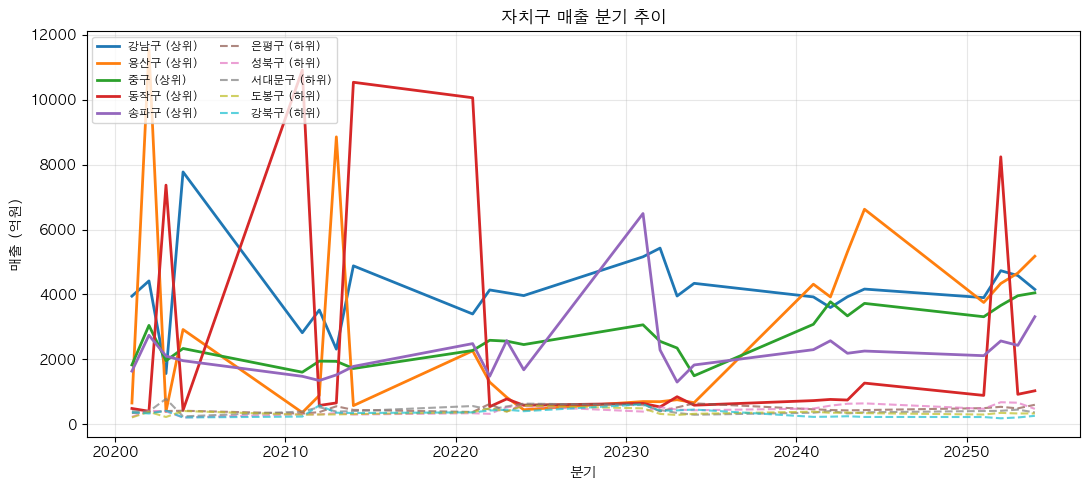

In [11]:
# 자치구·분기 매출을 피벗 → 행=자치구, 열=분기
ts = df.groupby(['gu','q_int'])['THSMON_SELNG_AMT'].sum().unstack('q_int').sort_index(axis=1)
gu_order = ts.sum(axis=1).sort_values(ascending=False)
top5, bot5 = gu_order.head(5).index.tolist(), gu_order.tail(5).index.tolist()

fig, ax = plt.subplots(figsize=(11, 5))
# 상위 5 자치구는 굵게, 하위 5는 점선으로 — 한 그래프에 25개 다 그리면 난잡
for gu in top5: ax.plot(ts.columns, ts.loc[gu]/1e8, label=f'{gu} (상위)', linewidth=2)
for gu in bot5: ax.plot(ts.columns, ts.loc[gu]/1e8, label=f'{gu} (하위)', linestyle='--', alpha=0.7)
ax.set_title('자치구 매출 분기 추이'); ax.set_xlabel('분기'); ax.set_ylabel('매출 (억원)')
ax.legend(ncol=2, fontsize=8, loc='upper left'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 그래프 2 — 업종별 매출 분포 박스플롯 (가독성 위해 상위 15만 표시)

/var/folders/4x/mgwzyv2s3pzg9td6yc28pwrh0000gn/T/ipykernel_18314/302024156.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=biz_sorted, showfliers=False)


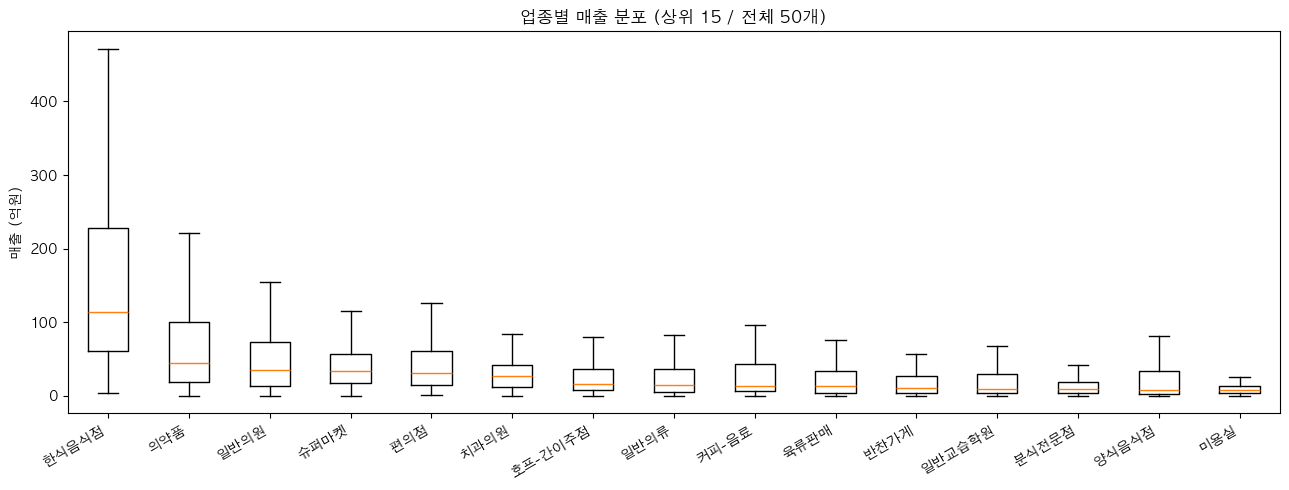

In [12]:
# 매출 중앙값 기준 내림차순으로 업종 정렬. 50개 전체 시각화는 난잡 → 상위 15만
biz_sorted_all = (df.groupby('biz')['THSMON_SELNG_AMT'].median()
                .sort_values(ascending=False).index.tolist())
biz_sorted = biz_sorted_all[:15]                                 # 시각화용 (15개)
data = [df.loc[df['biz']==b, 'THSMON_SELNG_AMT']/1e8 for b in biz_sorted]
fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(data, labels=biz_sorted, showfliers=False)
ax.set_title(f'업종별 매출 분포 (상위 15 / 전체 {len(biz_sorted_all)}개)'); ax.set_ylabel('매출 (억원)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## 그래프 3 — 자치구 × 업종 평균 매출 히트맵

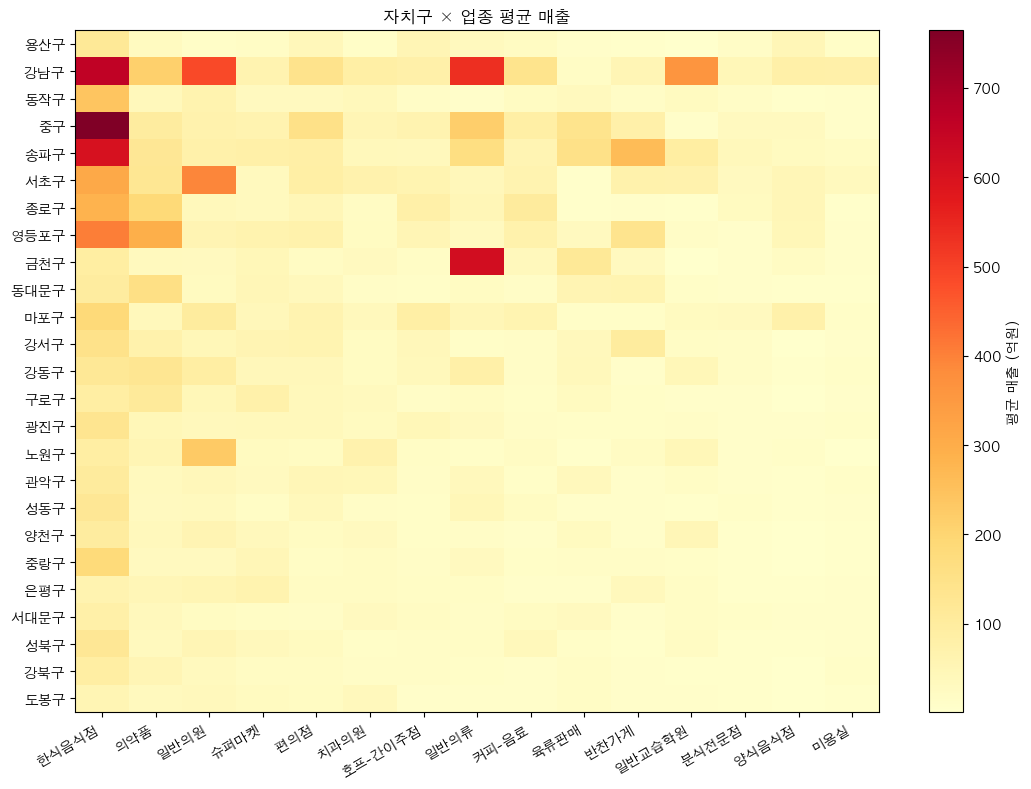

In [13]:
piv = df.pivot_table(index='gu', columns='biz', values='THSMON_SELNG_AMT', aggfunc='mean')/1e8
# 행=자치구를 평균 매출 내림차순, 열=업종을 위 그래프 순서대로
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index, biz_sorted]
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(piv.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(biz_sorted))); ax.set_xticklabels(biz_sorted, rotation=30, ha='right')
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
plt.colorbar(im, label='평균 매출 (억원)')
ax.set_title('자치구 × 업종 평균 매출'); plt.tight_layout(); plt.show()

## 그래프 4 — 핵심 변수 상관행렬 (신규 변수 포함)

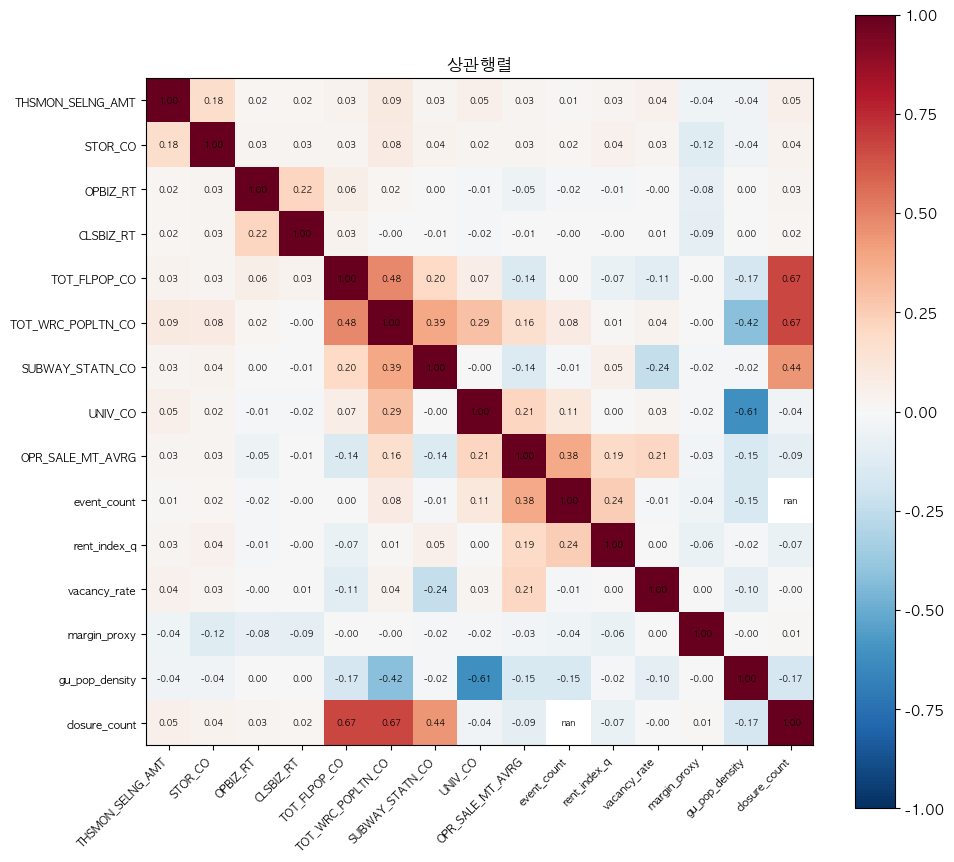

In [14]:
# 매출 + 신규 외부 변수의 상관 — 다중공선성 사전 점검
core_cols = ['THSMON_SELNG_AMT','STOR_CO','OPBIZ_RT','CLSBIZ_RT',
             'TOT_FLPOP_CO','TOT_WRC_POPLTN_CO',
             'SUBWAY_STATN_CO','UNIV_CO','OPR_SALE_MT_AVRG','event_count',
             'rent_index_q','vacancy_rate','margin_proxy',
             'gu_pop_density','closure_count']
present = [c for c in core_cols if c in df.columns]
corr = df[present].corr()
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(present))); ax.set_xticklabels(present, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(present))); ax.set_yticklabels(present, fontsize=8)
# 각 셀에 상관계수 값을 텍스트로 표기 — 한눈에 |r|>=0.9 짝 찾기 위함
for i in range(len(present)):
    for j in range(len(present)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.colorbar(im); ax.set_title('상관행렬'); plt.tight_layout(); plt.show()

## 그래프 5 — 유동인구 vs 매출 산점도 (업종별 색)

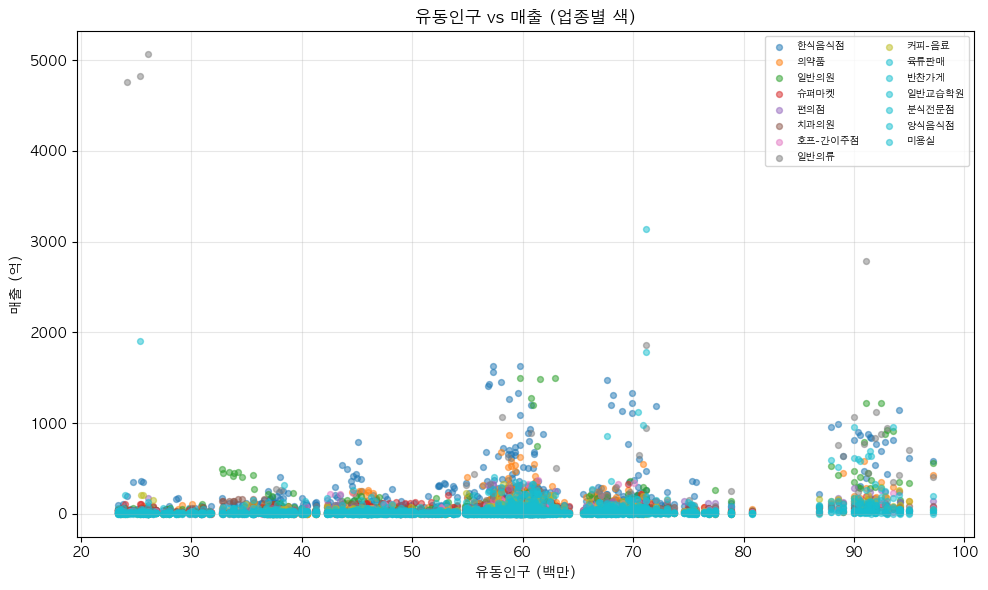

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.tab10
for i, b in enumerate(biz_sorted):
    sub = df[df['biz']==b]
    ax.scatter(sub['TOT_FLPOP_CO']/1e6, sub['THSMON_SELNG_AMT']/1e8,
               alpha=0.5, label=b, color=cmap(i), s=18)
ax.set_xlabel('유동인구 (백만)'); ax.set_ylabel('매출 (억)')
ax.set_title('유동인구 vs 매출 (업종별 색)')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 그래프 6 — 시간대 매출 비중 누적막대

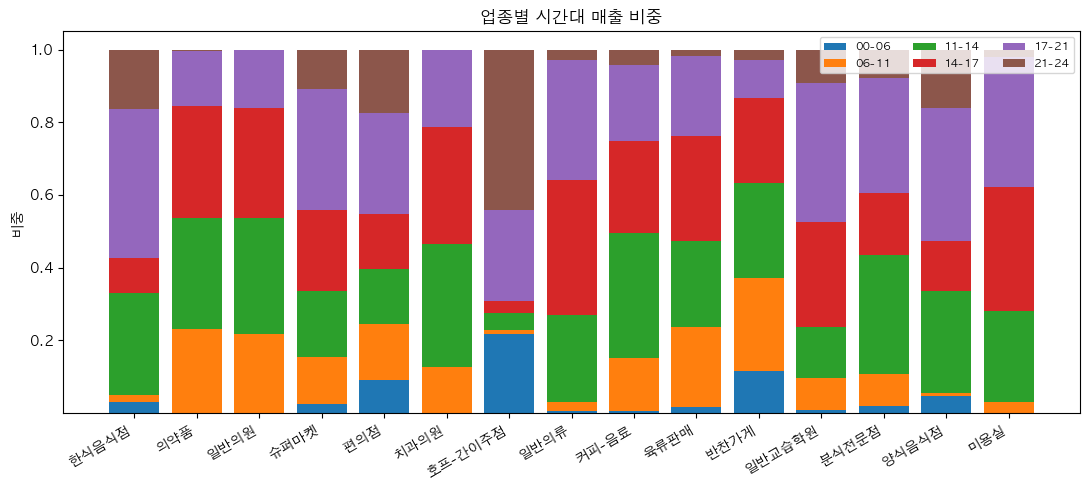

In [16]:
tz_cols = ['TMZON_00_06_SELNG_AMT','TMZON_06_11_SELNG_AMT','TMZON_11_14_SELNG_AMT',
           'TMZON_14_17_SELNG_AMT','TMZON_17_21_SELNG_AMT','TMZON_21_24_SELNG_AMT']
ratios = df.groupby('biz')[tz_cols].sum()
ratios = ratios.div(ratios.sum(axis=1), axis=0).loc[biz_sorted]      # 행 기준 비율로 정규화
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(ratios))                                       # 누적 막대 시작점
labels = ['00-06','06-11','11-14','14-17','17-21','21-24']
for i, col in enumerate(tz_cols):
    ax.bar(ratios.index, ratios[col], bottom=bottom, label=labels[i])
    bottom += ratios[col].values                                     # 다음 시간대는 그 위에 쌓기
ax.set_title('업종별 시간대 매출 비중'); ax.set_ylabel('비중')
plt.xticks(rotation=30, ha='right'); ax.legend(loc='upper right', fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

## 그래프 7 — 개업률 vs 폐업률 사분면

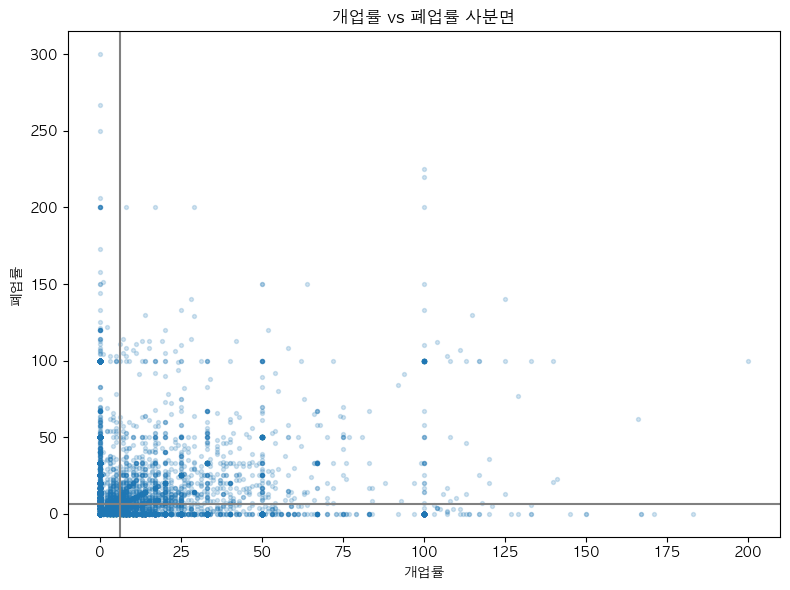

In [17]:
tmp = df.dropna(subset=['OPBIZ_RT','CLSBIZ_RT'])
op_mean, cl_mean = tmp['OPBIZ_RT'].mean(), tmp['CLSBIZ_RT'].mean()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(tmp['OPBIZ_RT'], tmp['CLSBIZ_RT'], alpha=0.2, s=8)
# 평균선으로 4사분면 분할 — 좌상 = 폐업 多 진입 少 등 해석
ax.axvline(op_mean, color='gray'); ax.axhline(cl_mean, color='gray')
ax.set_xlabel('개업률'); ax.set_ylabel('폐업률')
ax.set_title('개업률 vs 폐업률 사분면'); plt.tight_layout(); plt.show()

## 그래프 8 — 코로나 충격기 vs 회복기

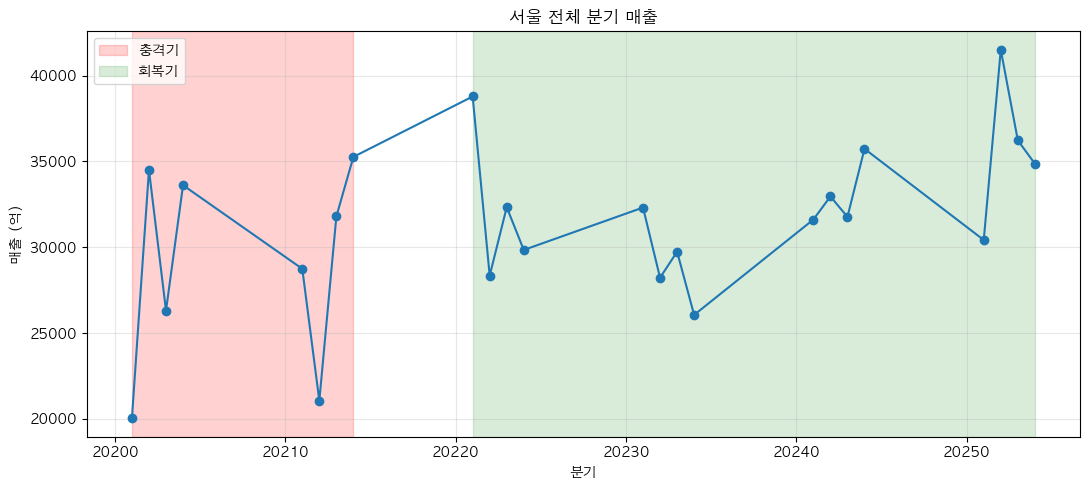

In [18]:
trend = df.groupby('q_int')['THSMON_SELNG_AMT'].sum() / 1e8
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(trend.index, trend.values, marker='o')
# 충격기(20Q1~21Q4) 빨강, 회복기(22Q1~) 초록 음영
ax.axvspan(20201, 20214, alpha=0.18, color='red', label='충격기')
ax.axvspan(20221, trend.index.max(), alpha=0.15, color='green', label='회복기')
ax.set_title('서울 전체 분기 매출'); ax.set_xlabel('분기'); ax.set_ylabel('매출 (억)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 그래프 9 — 임대료지수 시계열 (신규)

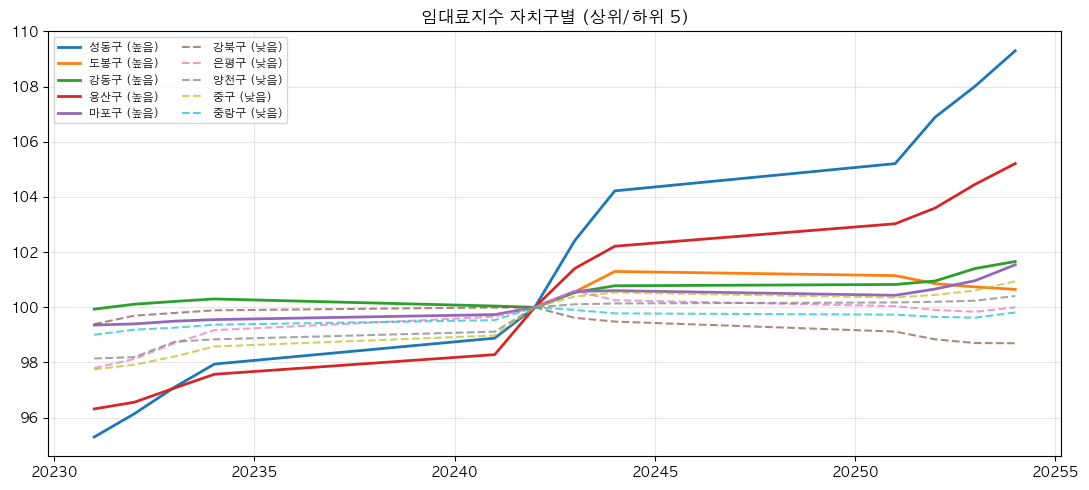

In [19]:
# 자치구별 임대료지수 시계열, 평균 기준 상위 5 / 하위 5만 표시
rent_ts = (df.dropna(subset=['rent_index_q'])
              .groupby(['gu','q_int'])['rent_index_q'].mean().unstack('q_int'))
top_high = rent_ts.mean(axis=1).sort_values(ascending=False).head(5).index
top_low  = rent_ts.mean(axis=1).sort_values().head(5).index
fig, ax = plt.subplots(figsize=(11, 5))
for gu in top_high: ax.plot(rent_ts.columns, rent_ts.loc[gu], label=f'{gu} (높음)', linewidth=2)
for gu in top_low:  ax.plot(rent_ts.columns, rent_ts.loc[gu], label=f'{gu} (낮음)', linestyle='--', alpha=0.7)
ax.set_title('임대료지수 자치구별 (상위/하위 5)')
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 그래프 10 — 공실률 자치구 분포 (신규)

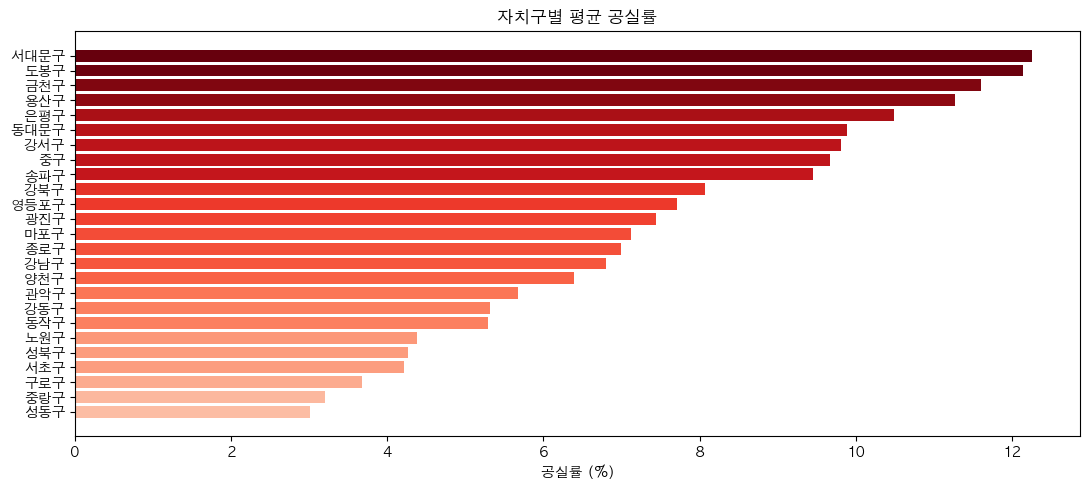

In [20]:
# 자치구별 평균 공실률 — 막대 색상은 공실률 크기에 비례 (높을수록 빨강 진해짐)
vac = df.dropna(subset=['vacancy_rate']).groupby('gu')['vacancy_rate'].mean().sort_values()
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(vac.index, vac.values, color=plt.cm.Reds(vac.values/vac.values.max()))
ax.set_title('자치구별 평균 공실률'); ax.set_xlabel('공실률 (%)')
plt.tight_layout(); plt.show()

## 그래프 11 — 폐업점포수 vs 매출 (신규)

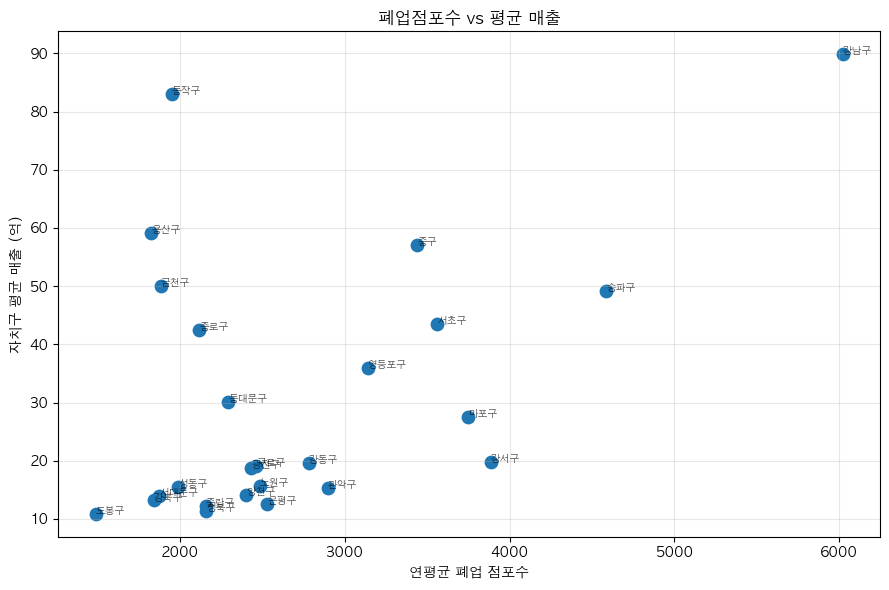

In [21]:
# 자치구별로 폐업점포수와 평균매출을 산점도로 표시
closure_avg = df.dropna(subset=['closure_count']).groupby('gu').agg(
    sales=('THSMON_SELNG_AMT', 'mean'),
    closure=('closure_count', 'mean')).reset_index()
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(closure_avg['closure'], closure_avg['sales']/1e8, s=80)
# 자치구명 표시 — 어느 점이 어느 자치구인지 식별
for _, r in closure_avg.iterrows():
    ax.annotate(r['gu'], (r['closure'], r['sales']/1e8), fontsize=7, alpha=0.7)
ax.set_xlabel('연평균 폐업 점포수'); ax.set_ylabel('자치구 평균 매출 (억)')
ax.set_title('폐업점포수 vs 평균 매출'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 다음 단계
- `data/processed/integrated.csv`: 후속 노트북의 입력
- `03_features.ipynb`: 가공 변수 생성